Name: Ashish Ranjan
Application No.: IN26012845
Email-id: ashish138169@gmail.com

# Real-Time Card-Not-Present Fraud Detection
**Domain:** FinTech / E-Commerce Payments  
**Algorithm Focus:** Support Vector Machines (SVM)  
**Dataset:** [Credit Card Fraud Detection (ULB Machine Learning Group)](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)

## Executive Summary
This project builds a robust classification engine to detect fraudulent credit card transactions. Due to the extreme class imbalance inherent in fraud detection, standard accuracy metrics are highly misleading. This notebook explores data separability, applies rigorous scaling, and utilizes Stratified Cross-Validation to evaluate Support Vector Machine (SVM) configurations, optimizing for Precision-Recall Area Under the Curve (PR-AUC) to minimize the operational costs of false positives and false negatives.

In [3]:
import sys
print(sys.executable)

d:\CardNotPresentFraudDetection\.venv\Scripts\python.exe


In [1]:
# Standard Data Manipulation
import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configure presentation-ready visualizations
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.figsize': (10, 6), 'font.size': 12})
warnings.filterwarnings('ignore')

print("Environment successfully initialized.")

Environment successfully initialized.


## 1. Data Loading and Structural Inspection
The dataset contains 28 anonymized numerical features resulting from a PCA transformation (V1-V28), plus `Time` and `Amount`. The target variable is `Class` (0 = Legitimate, 1 = Fraud).

In [2]:
# Load the dataset 
try:
    df = pd.read_csv('creditcard.csv')
    print(f"Dataset loaded successfully with {df.shape[0]:,} rows and {df.shape[1]} columns.")
except FileNotFoundError:
    print("Error: 'creditcard.csv' not found. Please ensure the dataset is in the working directory.")

# Check for missing values
missing_values = df.isnull().sum().max()
print(f"Maximum missing values in any column: {missing_values}")

# Display the first few rows
display(df.head())

Dataset loaded successfully with 284,807 rows and 31 columns.
Maximum missing values in any column: 0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Quantifying Class Imbalance
Fraud detection is inherently a rare-event modeling problem. One must understand the exact ratio of legitimate to fraudulent transactions to inform our cross-validation and evaluation strategies later.

Legitimate Transactions: 284,315
Fraudulent Transactions: 492
Percentage of Fraud: 0.173%



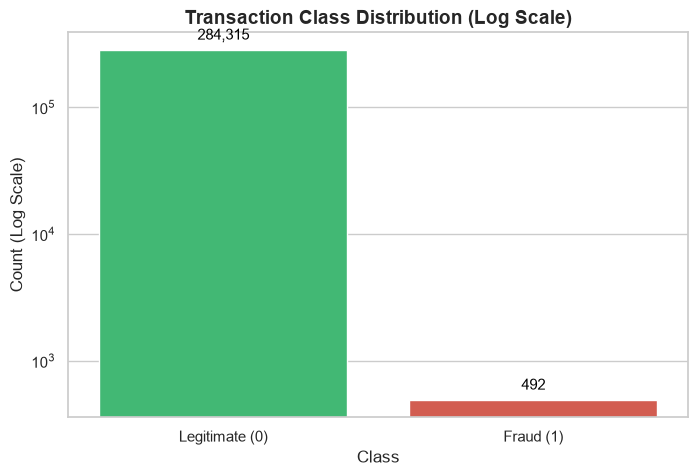

In [3]:
# Calculate exact class distribution
class_counts = df['Class'].value_counts()
legit_count = class_counts[0]
fraud_count = class_counts[1]
fraud_percentage = (fraud_count / len(df)) * 100

print(f"Legitimate Transactions: {legit_count:,}")
print(f"Fraudulent Transactions: {fraud_count:,}")
print(f"Percentage of Fraud: {fraud_percentage:.3f}%\n")

# Visualize the imbalance using a logarithmic scale for visibility
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df, x='Class', palette=['#2ecc71', '#e74c3c'], ax=ax)
ax.set_title('Transaction Class Distribution (Log Scale)', fontsize=14, fontweight='bold')
ax.set_xticklabels(['Legitimate (0)', 'Fraud (1)'])
ax.set_ylabel('Count (Log Scale)')
ax.set_yscale('log') # Log scale is required because fraud is so rare

# Annotate the bars with exact counts
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 5), 
                textcoords='offset points')
plt.show()

## 3. Feature Separability Analysis
Before modeling, One must investigate whether the features exhibit different distributions for fraud versus legitimate transactions. If the distributions overlap perfectly, an algorithm will struggle to separate them.

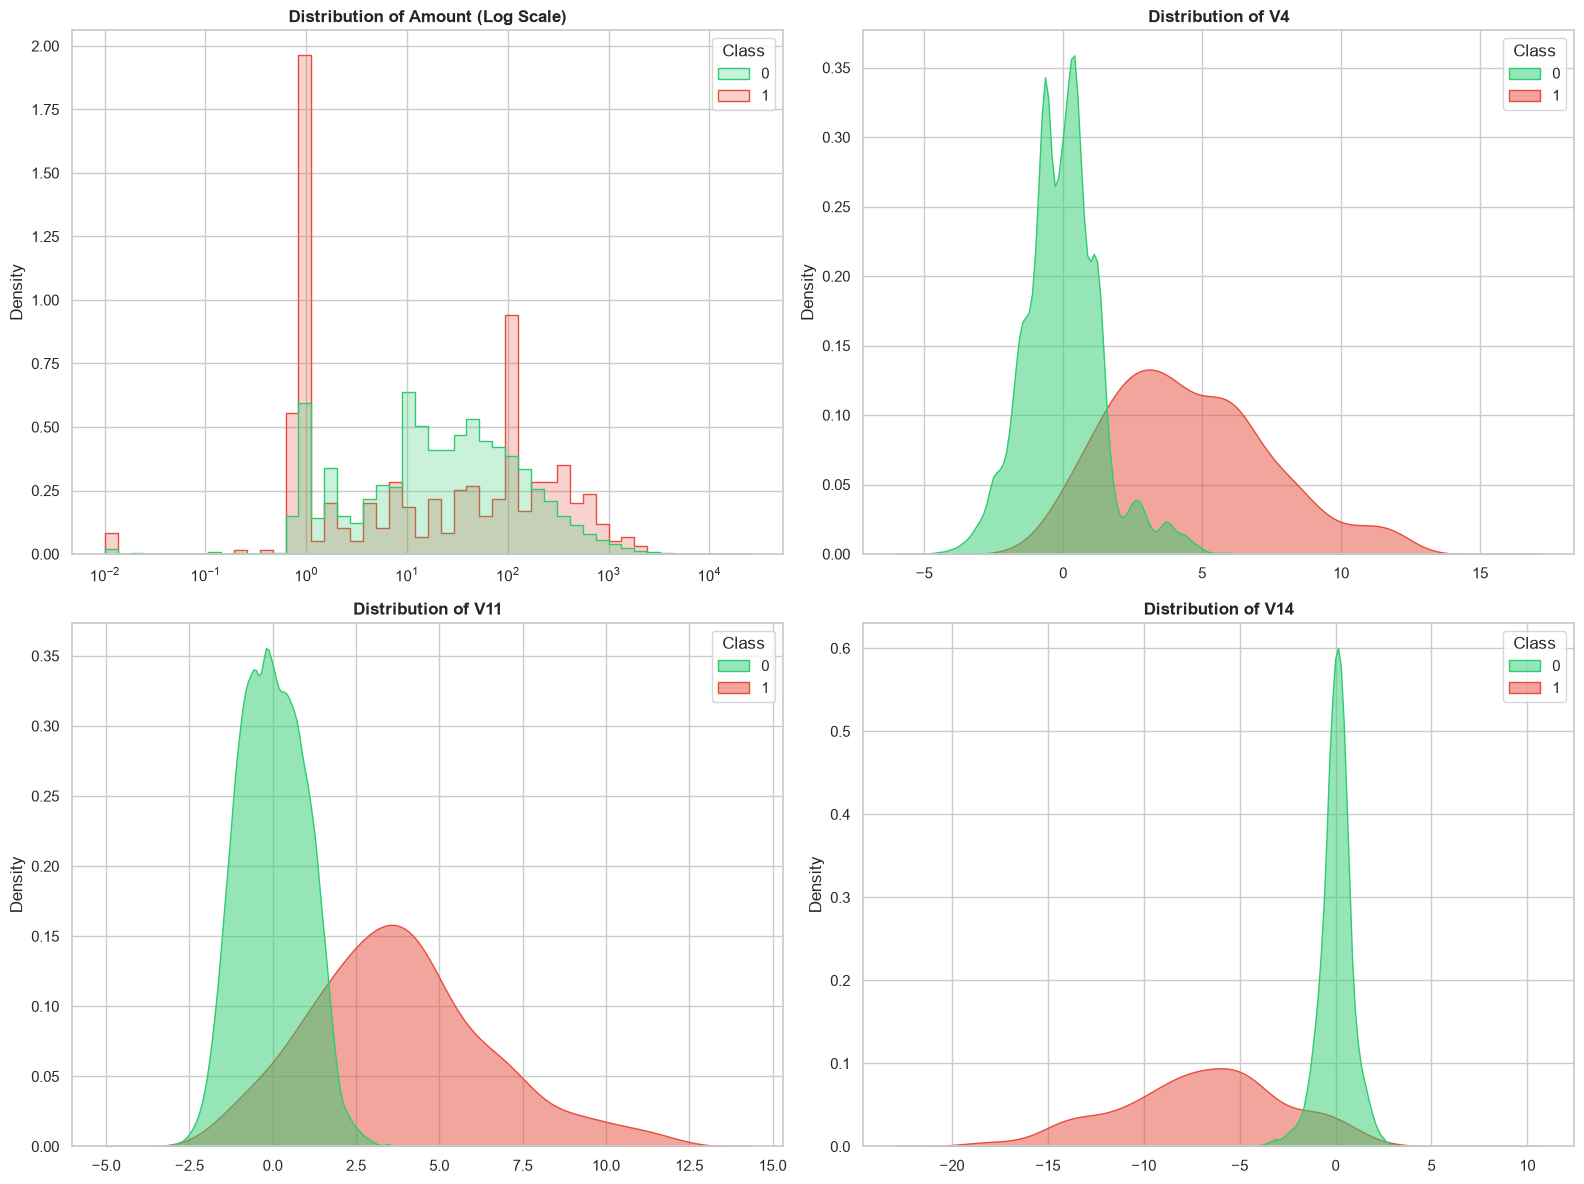

In [4]:
# Select a subset of features to analyze
features_to_plot = ['Amount', 'V4', 'V11', 'V14']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    if feature == 'Amount':
        sns.histplot(data=df, x=feature, hue='Class', bins=50, stat="density", 
                     common_norm=False, palette=['#2ecc71', '#e74c3c'], 
                     element="step", ax=axes[i], log_scale=True)
        axes[i].set_title(f'Distribution of {feature} (Log Scale)', fontweight='bold')
    else:
        sns.kdeplot(data=df, x=feature, hue='Class', fill=True, 
                    common_norm=False, palette=['#2ecc71', '#e74c3c'], 
                    alpha=0.5, ax=axes[i])
        axes[i].set_title(f'Distribution of {feature}', fontweight='bold')
        
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Density')

plt.tight_layout()
plt.show()

## 4. Preprocessing: Subsampling and Scaling
Support Vector Machines are distance-based algorithms, meaning features with larger numeric ranges (like `Amount`) will disproportionately influence the decision boundary. We must scale the features. We use `RobustScaler` because transaction amounts contain extreme outliers.

Additionally, because SVM training time scales quadratically (or worse) with the number of samples, we will create a 10% stratified subsample of the dataset to allow for feasible hyperparameter tuning without sacrificing the distribution of our rare fraud class.